## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Samuel Bromberg

**Date:** 9/29/2026

## Q1. Concept Review

1. **Regression vs. classification:** Regression predicts a number, like a house price or temperature. Classification predicts a category, like whether something is spam or not spam.

2. **Confusion table:** A confusion table compares the actual class to the model’s predicted class. It shows which categories the model gets right and which ones it often mixes up.

3. **SSE:** SSE, or sum of squared errors, adds up the squared differences between actual values and predicted values. A lower SSE means the predictions are closer to the real values, but low training SSE does not always mean the model will work well on new data.

4. **Overfitting and underfitting:** Overfitting happens when a model learns the training data too closely, including random noise, so it does poorly on new data. Underfitting happens when a model is too simple and cannot find the important patterns in the data.

5. **Train/test splitting and choosing `k`:** A test set should be saved for the end so it gives a fair estimate of how the model will perform on new data. We should choose `k` using the training data, usually with cross-validation, instead of repeatedly testing different values on the test set.

6. **Class label vs. probability distribution:** A class label gives one final prediction, while probabilities show how confident the model is in each possible class. Probabilities are more useful when the model is uncertain, but they should not be treated as guarantees.

First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1



Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Summary of features:


,voltage,height,soil
count,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550
std,0.195819,0.306043,0.344244
min,0.197734,0.000000,0.000000
25%,0.309737,0.272727,0.200000
50%,0.359516,0.545455,0.600000
75%,0.482628,0.727273,0.800000
max,0.999999,1.000000,1.000000


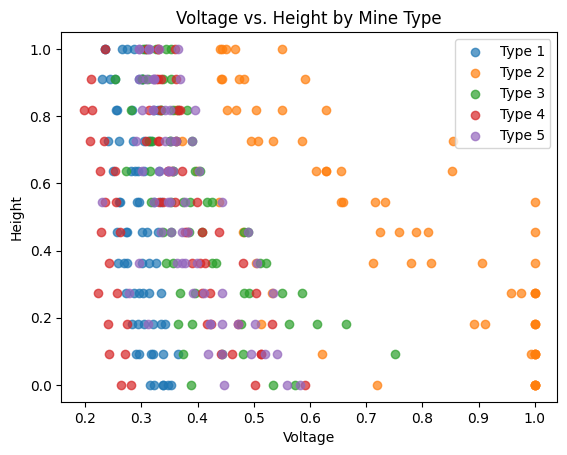


Training rows: 169
Testing rows: 169

Cross-validation scores:
k = 1 | average accuracy = 0.42
k = 3 | average accuracy = 0.396
k = 5 | average accuracy = 0.461
k = 7 | average accuracy = 0.479
k = 9 | average accuracy = 0.467
k = 11 | average accuracy = 0.42
k = 13 | average accuracy = 0.402
k = 15 | average accuracy = 0.396

Best k: 7

Test accuracy: 0.402

Confusion matrix:


,1,2,3,4,5
1,24,0,7,4,1
2,0,31,0,3,1
3,8,2,7,6,10
4,13,5,8,2,5
5,10,0,10,8,4


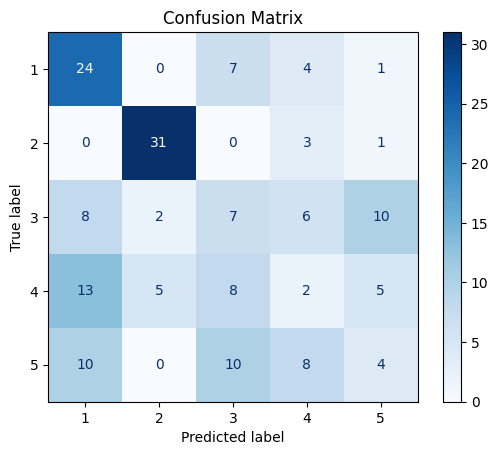


Number of incorrect predictions: 101

Most common mistakes:


,,count
actual,predicted,
4,1,13
5,1,10
3,5,10
5,3,10
3,1,8
5,4,8
4,3,8
1,3,7
3,4,6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# Load the data
mines = pd.read_csv("data/land_mines.csv")

# Choose the columns used for prediction
features = ["voltage", "height", "soil"]
X = mines[features]
y = mines["mine_type"]

# Look at the dataset
print("First five rows:")
display(mines.head())

print("\nMine type counts:")
print(y.value_counts().sort_index())

print("\nSummary of features:")
display(X.describe())


# Graph voltage and height by mine type
for mine_type in sorted(y.unique()):
    group = mines[mines["mine_type"] == mine_type]

    plt.scatter(
        group["voltage"],
        group["height"],
        label=f"Type {mine_type}",
        alpha=0.7
    )

plt.title("Voltage vs. Height by Mine Type")
plt.xlabel("Voltage")
plt.ylabel("Height")
plt.legend()
plt.show()


# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


# Try different k values using cross-validation
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
scores = []

for k in k_values:
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    scores.append(cv_score.mean())

# Print the average CV score for each k
print("\nCross-validation scores:")
for k, score in zip(k_values, scores):
    print("k =", k, "| average accuracy =", round(score, 3))

# Pick the k with the highest CV accuracy
best_k = k_values[scores.index(max(scores))]
print("\nBest k:", best_k)


# Train the final model with the best k
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k)
)

final_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = final_model.predict(X_test)


# Report final accuracy
test_accuracy = accuracy_score(y_test, predictions)
print("\nTest accuracy:", round(test_accuracy, 3))


# Create and display the confusion matrix
labels = sorted(y.unique())
matrix = confusion_matrix(y_test, predictions, labels=labels)

print("\nConfusion matrix:")
display(pd.DataFrame(
    matrix,
    index=labels,
    columns=labels
))

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=labels
).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


# Show the rows where the model made mistakes
errors = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

errors = errors[errors["actual"] != errors["predicted"]]

print("\nNumber of incorrect predictions:", len(errors))

if len(errors) > 0:
    print("\nMost common mistakes:")
    display(errors.value_counts().rename("count").to_frame())
else:
    print("No incorrect predictions in this test split.")

The dataset contains 338 observations across five fairly balanced mine types. I used voltage, height, and soil to build a k-NN model, splitting the data evenly into training and test sets while keeping each mine type represented in both. I used five-fold cross-validation on the training data to choose `k = 7`.

The model had 40.2% accuracy on the test set. It predicted types 1 and 2 better than types 3, 4, and 5, which were often confused with other mine types. Because of these errors, this model should only be used as an extra tool to guide inspection, not to decide whether an area is safe or how to handle a mine.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 44b0227
- **AI tool and model used:** Chat GPT 5.6 Terra

### *Prompts used

1. Can you look over my written answers and code and tell me what could be improved for Phase 2? Please do not change the required 50/50 train/test split or my original Phase 1 work.

2. Does my model-selection process make sense? I want to make sure I am choosing k correctly without using the test set too early. Please explain any issue simply and suggest a better approach.

3. What additional EDA would be useful for this land-mine dataset without making the notebook overly complicated? I need to summarize the mine-type labels and the three predictor variables.

4. Can you help me improve the confusion-matrix section? I want the table and interpretation to clearly show which mine types the model predicts well and which ones it mixes up.

5. Can you revise my practical recommendation for using this model? Since this is a land-mine classification example, I want to explain why the model should support trained human decision-making rather than be used by itself.

### *AI-proposed changes


1. Keep the original 50/50 stratified train/test split because it ensures every mine type is represented in both datasets. Do not modify the frozen Phase 1 work; place all revisions in the new Phase 2 cells.

2. Keep the basic EDA already completed, but add a table with each mine type’s count and percentage of the dataset. Add grouped feature means and simple boxplots for voltage, height, and soil by mine type to make differences between classes easier to see.

3. The current model-selection approach is mostly correct because it uses cross-validation on the training data rather than selecting k based on test accuracy. Make this clearer by using stratified five-fold cross-validation and explicitly stating that the test data is held out until the final evaluation.

4. Compare a slightly wider range of odd k values, such as 1 through 25. Odd values reduce the chance of tied votes, and choosing the k with the highest average cross-validation accuracy gives a more reliable choice than relying on one split of the data.

5. Improve the confusion-matrix display by labeling rows as actual mine types and columns as predicted mine types. Explain that diagonal values are correct predictions and off-diagonal values show specific mine types the model confuses.

6. Add a per-class performance table with precision, recall, F1-score, and support. Overall accuracy alone does not show whether the model performs much better for some mine types than for others.

7. Identify the most common incorrect actual-to-predicted mine-type combinations. Use these errors, along with the confusion matrix and recall values, to explain where performance is more or less accurate.

8. Revise the practical recommendation to state that the model should be used only as decision support for trained personnel. It may help prioritize inspections or indicate when further testing is needed, but it should never independently determine whether an area is safe or how a mine should be handled.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I kept the original Phase 1 work frozen and created new Phase 2 cells. I also kept the required 50/50 stratified train/test split. |
| 2 | Accept | I added class counts, percentages, grouped feature means, and boxplots. These additions provide more complete EDA without making the notebook too complicated. |
| 3 | Accept | My original approach already used cross-validation on the training data, which was appropriate. I revised it to use stratified five-fold cross-validation and clearly state that the test set is used only for final evaluation. |
| 4 | Accept with caveat | I expanded the comparison to odd k values from 1 through 25 and selected the value with the highest mean cross-validation accuracy. Odd k can reduce voting ties, but does not prevent ties when there are more than two classes. |
| 5 | Accept | I labeled the confusion table so that rows are actual mine types and columns are predicted mine types. This makes the correct predictions and classification errors easier to interpret. |
| 6 | Accept | I added precision, recall, F1-score, and support for each mine type. These measures show differences in performance across classes that overall test accuracy does not show. |
| 7 | Accept | I added a table of the most common incorrect predictions. I used it with the confusion matrix to identify which mine types the model most often confuses. |
| 8 | Accept | I revised the practical recommendation to emphasize that the model should support trained personnel rather than replace physical inspection, established safety procedures, or expert judgment. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

## Q1. Concept Review

**Regression vs. classification:** Regression predicts a numerical value, such as a house price or temperature. Classification predicts a category, such as whether an email is spam or which type of mine is present.

**Confusion table:** A confusion table compares the actual class labels with the model’s predicted class labels. Values on the diagonal are correct predictions, while off-diagonal values show the categories that the model confuses. It helps show whether the model performs better for some classes than others.

**SSE:** SSE, or sum of squared errors, adds the squared differences between actual values and predicted values. A lower SSE means the predicted values are generally closer to the actual values. However, a low training SSE does not guarantee that the model will perform well on new data.

**Overfitting and underfitting:** Overfitting happens when a model learns the training data too closely, including random noise, and then performs poorly on new data. Underfitting happens when a model is too simple to capture important patterns in the data.

**Train/test splitting and choosing k:** The test set should be saved for the final evaluation so that it gives a fair estimate of performance on new data. We should choose k using cross-validation on the training data rather than repeatedly checking test accuracy. This helps avoid choosing a model that happens to work well only on one particular test set.

**Class labels vs. probability distributions:** A class label gives one final prediction and is simple to understand. A probability distribution shows how confident the model is in each possible class, which can be useful when the model is uncertain. However, probabilities are not guarantees and should be interpreted carefully, especially in high-stakes situations.

Dataset shape: (338, 4)

First five rows:


,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1



Mine type counts and percentages:


,count,percent
mine_type,,
1,71,21.0
2,70,20.7
3,66,19.5
4,66,19.5
5,65,19.2



Overall feature summary:


,voltage,height,soil
count,338.000,338.000,338.000
mean,0.431,0.509,0.504
std,0.196,0.306,0.344
min,0.198,0.000,0.000
25%,0.310,0.273,0.200
50%,0.360,0.545,0.600
75%,0.483,0.727,0.800
max,1.000,1.000,1.000



Average feature values by mine type:


,voltage,height,soil
mine_type,,,
1,0.296,0.496,0.493
2,0.721,0.487,0.509
3,0.402,0.528,0.497
4,0.345,0.507,0.503
5,0.380,0.530,0.517


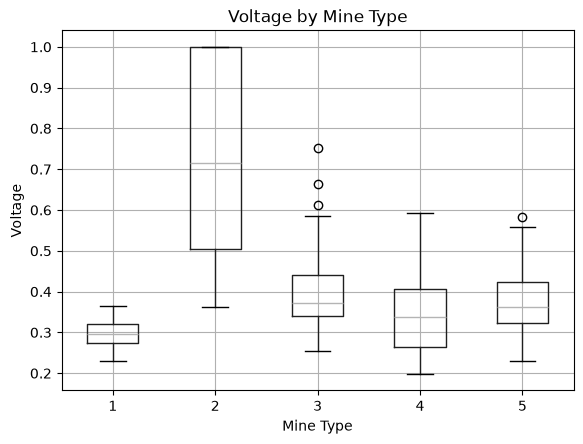

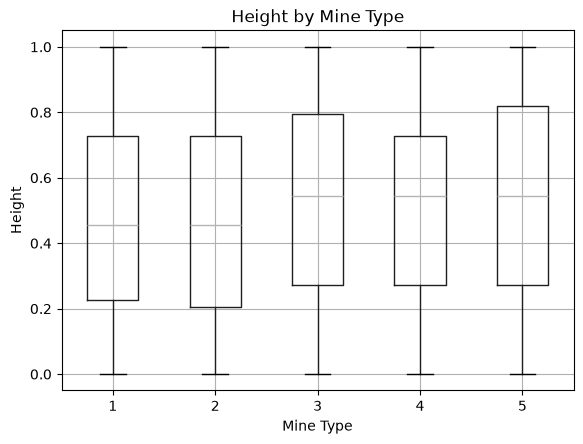

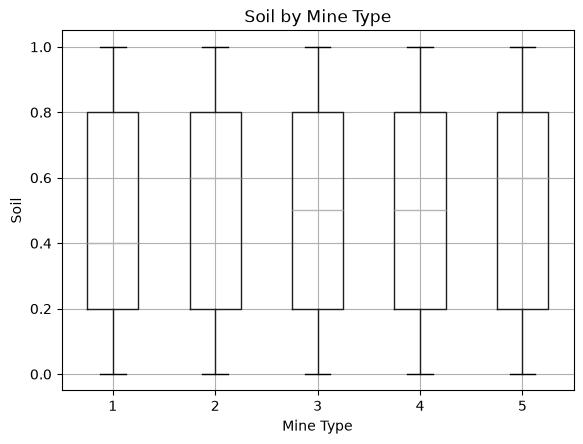


Training rows: 169
Test rows: 169

Cross-validation results:


,k,mean_cv_accuracy
0,1,0.469
1,3,0.479
2,5,0.486
3,7,0.444
4,9,0.468
5,11,0.445
6,13,0.433
7,15,0.356
8,17,0.373
9,19,0.361



Selected k: 5


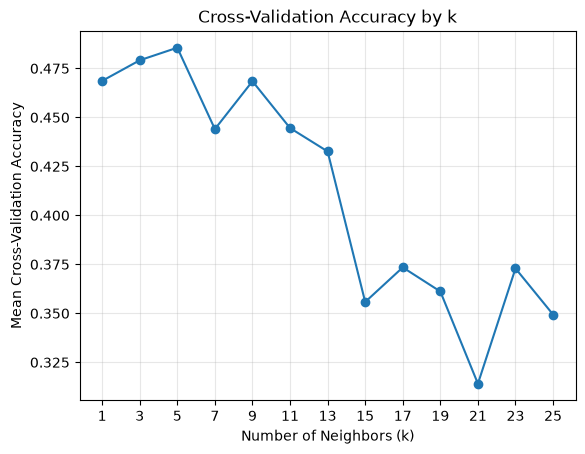


Final test accuracy: 0.42

Confusion table:


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,26,0,6,3,1
Actual 2,0,32,0,2,1
Actual 3,8,3,4,8,10
Actual 4,13,5,7,5,3
Actual 5,7,0,10,11,4


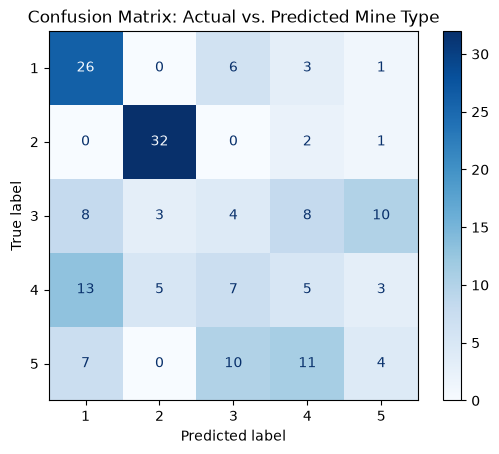


Performance by mine type:


,precision,recall,f1-score,support
1,0.481,0.722,0.578,36.0
2,0.800,0.914,0.853,35.0
3,0.148,0.121,0.133,33.0
4,0.172,0.152,0.161,33.0
5,0.211,0.125,0.157,32.0



Number of incorrect predictions: 98

Most common mistakes:


,actual,predicted,count
0,4,1,13
1,5,4,11
2,3,5,10
3,5,3,10
4,3,1,8
5,3,4,8
6,4,3,7
7,5,1,7
8,1,3,6
9,4,2,5


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Load the data
mines = pd.read_csv("data/land_mines.csv")

# Define predictors and target
features = ["voltage", "height", "soil"]
X = mines[features]
y = mines["mine_type"]

# EDA
print("Dataset shape:", mines.shape)

print("\nFirst five rows:")
display(mines.head())

print("\nMine type counts and percentages:")
mine_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(1)
})
display(mine_summary)

print("\nOverall feature summary:")
display(X.describe().round(3))

print("\nAverage feature values by mine type:")
display(mines.groupby("mine_type")[features].mean().round(3))

# Boxplots show how each feature differs by mine type
for feature in features:
    mines.boxplot(column=feature, by="mine_type")
    plt.title(feature.title() + " by Mine Type")
    plt.suptitle("")
    plt.xlabel("Mine Type")
    plt.ylabel(feature.title())
    plt.show()

# Split data 50/50 while keeping class proportions similar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))

# Choose k using only the training data
k_values = list(range(1, 26, 2))
mean_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    mean_scores.append(scores.mean())

cv_results = pd.DataFrame({
    "k": k_values,
    "mean_cv_accuracy": mean_scores
})

print("\nCross-validation results:")
display(cv_results.round(3))

best_k = cv_results.loc[
    cv_results["mean_cv_accuracy"].idxmax(),
    "k"
]

print("\nSelected k:", best_k)

# Plot cross-validation accuracy for each k
plt.plot(k_values, mean_scores, marker="o")
plt.title("Cross-Validation Accuracy by k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

# Train the final model using the selected k
final_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k)
)

final_model.fit(X_train, y_train)
predictions = final_model.predict(X_test)

# Report final test accuracy
test_accuracy = accuracy_score(y_test, predictions)
print("\nFinal test accuracy:", round(test_accuracy, 3))

# Create a labeled confusion table
labels = sorted(y.unique())
matrix = confusion_matrix(y_test, predictions, labels=labels)

confusion_table = pd.DataFrame(
    matrix,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

print("\nConfusion table:")
display(confusion_table)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=labels
).plot(cmap="Blues")

plt.title("Confusion Matrix: Actual vs. Predicted Mine Type")
plt.show()

# Show precision, recall, and F1-score for each mine type
report = classification_report(
    y_test,
    predictions,
    labels=labels,
    output_dict=True,
    zero_division=0
)

class_results = pd.DataFrame(report).transpose()
class_results = class_results.loc[
    [str(label) for label in labels],
    ["precision", "recall", "f1-score", "support"]
]

print("\nPerformance by mine type:")
display(class_results.round(3))

# Find the most common errors
errors = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": predictions
})

errors = errors[errors["actual"] != errors["predicted"]]

print("\nNumber of incorrect predictions:", len(errors))

print("\nMost common mistakes:")
display(
    errors.value_counts()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)

## Q2. Land-Mine Classification

The dataset has 338 observations, with 65–71 examples in each of the five mine types, so the classes are close to balanced. Mine type 2 has a noticeably higher average voltage than the other types, while average height and soil values are similar across classes. The boxplots also show substantial overlap, especially for height and soil, which helps explain why several types are difficult to distinguish.

I kept the required stratified 50/50 split, giving 169 training observations and 169 held-out test observations. I standardized the features inside a pipeline and selected `k` using stratified five-fold cross-validation on the training data only. Among the odd values from 1 to 25, `k = 5` had the highest mean cross-validation accuracy (0.486). The test set was used only for this final evaluation.

The final test accuracy was 0.420 (71 of 169 predictions correct). Performance varied substantially by type: recall was 0.722 for type 1 and 0.914 for type 2, but only 0.121 for type 3, 0.152 for type 4, and 0.125 for type 5. The model most often confused actual type 4 as type 1 (13 cases), actual type 5 as type 4 (11), and types 3 and 5 with each other (10 cases in each direction). Thus, the overall accuracy hides particularly poor detection of types 3–5.

This model should not be used to declare an area safe, identify or handle a mine, or replace established procedures and trained personnel. At most, after substantial independent validation, it could be considered a limited decision-support signal for prioritizing further expert inspection. Its low and uneven recall means that a prediction, especially for types 3–5, cannot rule out a different mine type or justify reduced precautions.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements AI helped me make were inluding class percentages, feature summaries, and boxplots to help visuallize the data easier. It also helped me implement a better five-fold cross-validation and per-class percision/recall along with my confusion matrix. 

I noticed that the AI generated phase 2 code initually used a dataset path that didn't match my workspace (VS Code). Running it revealed the error and I changed it to "data/land_mines.csv" which is the correct path. 

In my AI output I checked to make sure that odd `k` values may reduce ties, but with five classes they dont rule out the ties. 

The updated phase 2 ran successfully with 338 observations 50/50 test/train split and selected `k = 5` and 42% test accuracy. I found this interesting because my phase 1 code chose `k = 7` and accuracy of ~40%. 

Some remaining concerns are that my results vary by class with low recall for types 3-5. This model should also not replace trained experts or be used to fully determine mine safety. 

